<center>
    <h1 style = "color:blue" "align=center"; > ISAT341-Data Science and Machine Learning </h1>
</center>

<center>
    <font face="Courier">
    <h2 style = "color:blue" "align=center"; > Lab 5- Classification using Logistic Regression </h2>
</center>
    
<center>
    <img src="images/machine-learning%20(1).jpg" width=200; height=200>

<center>
<h2 style = "color:red" "align=center"; > Logistic Regression Classification with Imported Data (cardiology dataset) </h2>

<center>
    <h3>By Joshua Brewington</h3>
    </center>
<u>Objectives</u>
    
- Create and use Machine Learning Models with ScitKit Learn
- Learn more advanced NumPy (Numerical Python) features
- Learn how import data from remote websites (UCI Machine Learning Datasets)
- Train-test Split of data with ScitKit Learn
- Perform Classification with ScitKit Learn
- Create Predictive Models
- Perform Model Evaluation
        - Model Score and Accuracy
        - Compute Class Membership Probabilities
- Decision Boundary Plotting with MatPlotLib (not this lab)

### Description

Logistical regression will be implemented on the dataset by taking the dependent variable (variable class) and the other ones as features or predictor variables. we will use supervised learning to manipulate data to solve the problem of which patients have which diseases.

<center>
    <img src="images/cardiolog_dataset.png" width=450; height=450>

### Import the packages

In [1]:
#import packages
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

### Importing the CSV file

In [2]:
#import csv
import pandas as pd

df = pd.read_csv('data/CardiologyNumerical_Lab5.csv', encoding='utf')
df.head(5)

,angina,slope,thal,class
0,1,2,7,0
1,0,1,3,1
2,1,2,3,1
3,0,2,7,0
4,1,3,7,0


### Create the target vector

In [3]:
# The target vector is a 1D column vector

y=df['class']

### Create the feature matrix

In [4]:
# The feature matrix is a 2D array with n features

X=df[['angina','slope','thal']]

### Use the values property to cast the ojbect to numpy arrays

In [5]:
# Use the values property

y=df['class'].values
X=df[['angina','slope','thal']].values

### Use the numpy method

In [6]:
# Use the to_numpy() method of the dataframe to cast the objects

y=df['class'].to_numpy()
X=df[['angina','slope','thal']].to_numpy()

### Convert the object to numpy arrays

In [7]:
# Use the numpy to directly covert the dataframe object to numpy arrays as in import numpy as np

y=np.array(df['class'])
X=np.array(df[['angina','slope','thal']])

### Split and train the data with ScitKit Learn

In [8]:
from sklearn.model_selection import train_test_split

#test_size=.20 means the test consists of 20% of the data
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2,random_state=0)

### check the shape of your feature and target data

In [9]:
print('X_train Shape of the data : {}'.format(X_train.shape))
print('y_train Shape of the data : {}'.format(y_train.shape))

# This displays the shape of the training sets

X_train Shape of the data : (242, 3)
y_train Shape of the data : (242,)


In [10]:
print('X_test Shape of the data : {}'.format(X_test.shape))
print('y_test Shape of the data : {}'.format(y_test.shape))

# This displays the shape of the testing sets

X_test Shape of the data : (61, 3)
y_test Shape of the data : (61,)


### Perform Logistic Regression Analysis with ScitKit Learn

In [11]:
from sklearn.linear_model import LogisticRegression

logr = LogisticRegression(solver='newton-cg',
                       multi_class='multinomial',
                       random_state=0)
logr.fit(X_train, y_train)

# The x and y training datasets were fit to the LogisticRegression package

LogisticRegression(multi_class='multinomial', random_state=0,
                   solver='newton-cg')

### Test the accuracy

In [12]:
y_pred = logr.predict(X_test)
print("Test set predictions:\n {}".format(y_pred))
print('Test accuracy: {0:0.2f}'.format(logr.score(X_test, y_test)))
# Here we tested for accuracy of the model

Test set predictions:
 [1 1 1 1 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 1 1 1
 1 1 1 1 0 0 1 0 0 0 0 0 0 1 1 1 0 0 1 1 1 0 0 1]
Test accuracy: 0.82


### Predict class-membership probability

In [13]:
print('For the arbitray sample with feature values{0}\n'.
      format(np.array(X_test[:3,:])))
print('The predicted probability for belonging to the classes[class=0  class=1] are {0}'.
     format(logr.predict_proba(X_test[:3,:])))
print('\nThe sum of the columns is {}'.format(logr.predict_proba(X_test[:3,:]).sum(axis=1)))

# We are depicting the prediction of class member probabilites. All of the columns sum up to 1

For the arbitray sample with feature values[[0 2 3]
 [0 1 3]
 [0 2 3]]

The predicted probability for belonging to the classes[class=0  class=1] are [[0.22729701 0.77270299]
 [0.12138694 0.87861306]
 [0.22729701 0.77270299]]

The sum of the columns is [1. 1. 1.]


### Printing the class membership probablities for a Single Row of Data

In [14]:
print('The predicted probability for belonging to the classes[class=0  class=1] are {0}'.
     format(logr.predict_proba(X_test[1:2])))

# This is the predicted probability for one row of data.

The predicted probability for belonging to the classes[class=0  class=1] are [[0.12138694 0.87861306]]


### Create a Machine Learning Model

In [15]:
print('The coefficients from logistic regression are  {}'.format(logr.coef_))
print('The intercept from logistic regression is  {}'.format(logr.intercept_))
# Here we extracted the coefficients and intercept for the logistic regression model.

The coefficients from logistic regression are  [[-0.70468141 -0.37786208 -0.25425702]]
The intercept from logistic regression is  [2.1303138]


## <u>Equation:</u>

> <h3 style = "color:orange">z = -0.705 *Angina -0.378 * Slope -0.254 * Thal + 2.131</h3>

The equation is set up as z = wx + b, with w being coefficients and b being the intercept of a multivariate equation. 'z' is the target vector 'class'.

### Predictions with sigmoid function

In [16]:
Z = 1/(1+np.exp(-X))
def sigmoid(z):
    return 1/(1+np.exp(-z))

angina,slope,thal = 0,2,3

z = -0.705*angina - 0.378*slope - 0.254*thal + 2.131
print('The sigmoid function at this z is {0:.2f} and the probability rounds to {1:0.1f}'.format(sigmoid(z),round(sigmoid(z))))

# the first iteration

The sigmoid function at this z is 0.65 and the probability rounds to 1.0


In [17]:
angina,slope,thal = 1,3,6

z = -0.705*angina - 0.378*slope - 0.254*thal + 2.131
print('The sigmoid function at this z is {0:.2f} and the probability rounds to {1:0.1f}'.format(sigmoid(z),round(sigmoid(z))))

# the second iteration

The sigmoid function at this z is 0.23 and the probability rounds to 0.0


In [18]:
angina,slope,thal = 0,1,3

z = -0.705*angina - 0.378*slope - 0.254*thal + 2.131
print('The sigmoid function at this z is {0:.2f} and the probability rounds to {1:0.1f}'.format(sigmoid(z),round(sigmoid(z))))

# the third iteration

The sigmoid function at this z is 0.73 and the probability rounds to 1.0


What is the predicted class if the patient has the values below?

<table>
  <thead>
    <tr>
      <th>Angina</th>
      <th>Slope</th>
      <th>Thal</th>
      <th>Known Class</th>
      <th>Values from the Logistic Regression Model</th>
      <th>Predicted Class from the Logistic Regression Model</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>0</td>
      <td>2</td>
      <td>3</td>
      <td>1</td>
      <td>0.65</td>
      <td>1</td>
    </tr>
    <tr>
      <td>1</td>
      <td>3</td>
      <td>6</td>
      <td>0</td>
      <td>0.23</td>
      <td>0</td>
    </tr>
    <tr>
      <td>0</td>
      <td>1</td>
      <td>3</td>
      <td>1</td>
      <td>0.73</td>
      <td>1</td>
    </tr>
  </tbody>
</table>


#### Does the model correctly classify the instances?

It correctly classifies the instances because the predicted classes from the logistic regression model line up with the known classes.

### Classification report

In [19]:
# Import classifiers and performance metrics
from sklearn import metrics
print('Classification report for classifier {0} \n {1:s} \n'.format(logr,\
            metrics.classification_report(y_test, y_pred,target_names=['0','1'])))

Classification report for classifier LogisticRegression(multi_class='multinomial', random_state=0,
                   solver='newton-cg') 
               precision    recall  f1-score   support

           0       0.74      0.88      0.81        26
           1       0.90      0.77      0.83        35

    accuracy                           0.82        61
   macro avg       0.82      0.83      0.82        61
weighted avg       0.83      0.82      0.82        61
 



### Confusion Matrix

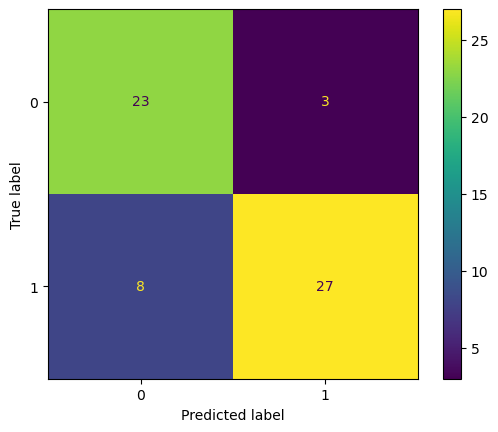

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test,y_pred,labels=logr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logr.classes_)
disp.plot()
plt.show()

## <u>Bonus Questions

BQ1- (**3pts**) Based on the output of your classification report and confusion matrix, out of all the times a patient should have been predicted as healthy, what percerntage of times were they correctly predicted? Show a simple calulation in below (**in your notebook**) since you already know the answer!

**ANSWER:**

The Answer is 0.81.

Accuracy = (TA+TR)/(TA+FA+FR+TR)

(23+27)/(23+3+8+27)

BQ2 - (**3pt**) Based on the output of your classification report and confusion matrix, out of all the times a patient was *predicted as sick*, what percentage of times were they correctly predicted? Show a simple calculation below (**in your notebook**) since you already know the answer!

For a simple (hypothetical) binary classification model. (When possible, show simple calculations in your notebook):

**ANSWER:**

The answer is 0.18.

Error = 1 - Accuracy

1 - (23+27)/(23+3+8+27)

BQ3-(**1pt**) If the recall is 1.0 and the dataset has 8 positive samples, how many positive samples were correctly classified by the model?

**ANSWER:**

8 samples

BQ4- (**2pts**) Given that the recall is 0.4 when the dataset has 40 positive samples, how many positive samples were correctly classified by the model? (**Must** show a simple calculation in your notebook for this one)

**ANSWER:**

0.4 * 40 = 16 positive samples

BQ5 - (**1pt**) If the recall is 0.0 and the dataset has 16 positive samples, how many positive samples were correclty classiied the model?

**ANSWER:**

0